In [1]:
from chembl_webresource_client.new_client import new_client # python API 
import pandas as pd
import numpy as np

In [2]:
activity = new_client.activity
results = activity.filter(
    target_chembl_id = "CHEMBL251",
    standard_type = "IC50"  
).only(
    "molecule_chembl_id",
    "canonical_smiles",
    "standard_value"
)


df = pd.DataFrame(results)
df.head()


,canonical_smiles,molecule_chembl_id,standard_value,value
0,CCCSc1c2c(nc(N)n3nc(-c4ccco4)nc23)nn1C,CHEMBL280888,14.8,14.8
1,COc1ccc(NC(=O)Nc2nc3nn(C)c(SC)c3c3nc(-c4ccco4)...,CHEMBL22113,17.5,17.5
2,CCNc1c2c(nc(NC(=O)Nc3ccc(OC)cc3)n3nc(-c4ccco4)...,CHEMBL554955,61.0,61.0
3,CSc1c2c(nc(NC(=O)Cc3ccc4c(c3)OCO4)n3nc(-c4ccco...,CHEMBL21572,21.5,21.5
4,CSc1c2c(nc(N)n3nc(-c4ccco4)nc23)nn1C,CHEMBL281129,6.1,6.1


In [3]:
df.shape

(3003, 4)

In [4]:
# Clean the data
df = df.dropna()
df = df[df["standard_value"].notnull()]
df['standard_value'] = pd.to_numeric(df['standard_value'], errors='coerce')

df = df.dropna()

df = df.drop_duplicates(subset='canonical_smiles')
df.shape

(1738, 4)

In [5]:
# Convert IC50 to pIC50, pIC50 = -log10(IC50 in molar)
df['pIC50'] = 9 - np.log10(df['standard_value'])


<Axes: >

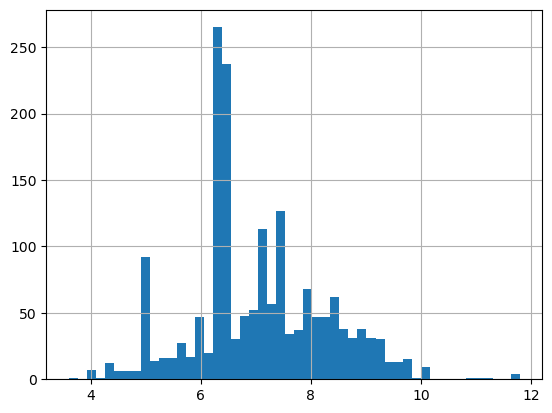

In [6]:
df['pIC50'].hist(bins=50)

In [7]:
from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np

In [8]:
df["mol"] = df["canonical_smiles"].apply(Chem.MolFromSmiles) # SMILES -> molecule


In [9]:
# create fingerprint
from rdkit.Chem import rdFingerprintGenerator
morgan_gen =  rdFingerprintGenerator.GetMorganGenerator(radius = 2, fpSize = 2048)
def mol_to_fp(mol):
    fp = morgan_gen.GetFingerprint(mol)
    return np.array(fp)
    
df["fp"] = df["mol"].apply(mol_to_fp)

df.to_csv("A2AR_IC50.csv", index=False)


In [10]:
df.shape

(1738, 7)

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

In [34]:
# create dataset for ML
X = np.stack(df["fp"].values)
y = df["pIC50"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
# create ML model
# RandomForestRegressor
model = RandomForestRegressor(n_estimators=200)
model.fit(X_train, y_train)


,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [14]:
y_pred = model.predict(X_test)
print("R2:",r2_score(y_test,y_pred))

R2: 0.6731821726363988


In [15]:
import numpy as np

y_train = np.array(y_train).astype(str)
y_train = np.char.replace(y_train, "[", "")
y_train = np.char.replace(y_train, "]", "")
y_train = y_train.astype(float)

y_test = np.array(y_test).astype(str)
y_test = np.char.replace(y_test, "[", "")
y_test = np.char.replace(y_test, "]", "")
y_test = y_test.astype(float)

In [16]:
from xgboost import XGBRegressor
model = XGBRegressor(
    n_estimators = 500,
    max_depth = 8,
    learning_rate = 0.01,
    subsample = 0.8,
    colsample_bytree = 0.8,
    random_state = 42
)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

print("R2:", r2_score(y_test, y_pred))

R2: 0.673681395525467


In [17]:
# Scaffold split
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold

# Generate Scaffold for Each Molecule
def get_scaffold (mol): 
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    return Chem.MolToSmiles(scaffold)
    
df["scaffold"] = df["mol"].apply(get_scaffold)
print(df["scaffold"].nunique())
scaffold_groups = df.groupby("scaffold")
# create scaffold list
scaffold_list = list(scaffold_groups.groups.keys())

import random
random.seed(42)
random.shuffle(scaffold_list)
split = int(len(scaffold_list)*0.8)

train_scaffolds = scaffold_list[:split]
test_scaffolds = scaffold_list[split:]
train_df = df[df["scaffold"].isin(train_scaffolds)]
test_df = df[df["scaffold"].isin(test_scaffolds)]

print(len(train_df),len(test_df))

605
1333 405


In [18]:
import numpy as np
X_train = np.stack(train_df["fp"].values)
y_train = train_df["pIC50"].values
X_test = np.stack(test_df["fp"].values)
y_test = test_df["pIC50"].values

In [19]:
model = RandomForestRegressor(n_estimators=200)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2:", r2_score(y_test, y_pred))

R2: 0.5962273783475833


In [20]:
# Create XGBRegressor
from xgboost import XGBRegressor

In [21]:
model = XGBRegressor(
    n_estimators = 500,
    max_depth = 8,
    learning_rate = 0.01,
    subsample = 0.8,
    colsample_bytree = 0.8,
    random_state = 42
)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

print("R2:", r2_score(y_test, y_pred))

R2: 0.6186250597530308


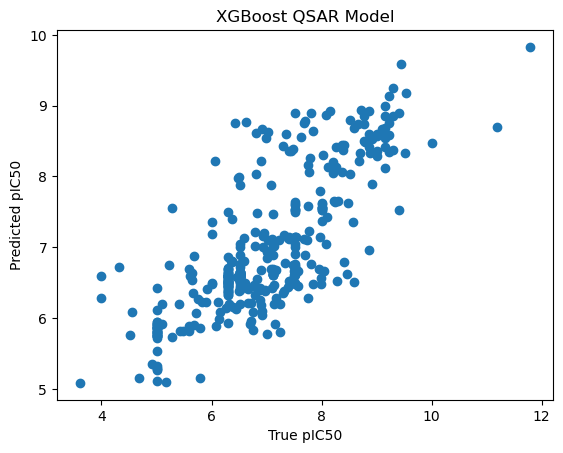

In [22]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("True pIC50")
plt.ylabel("Predicted pIC50")
plt.title("XGBoost QSAR Model")
plt.show()

In [23]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 0.7570344679604518


# Hyperparameter tuning

In [24]:

from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score


In [25]:
# basic model
xgb = XGBRegressor(
    objective = "reg:squarederror",
    random_state = 42
)
# parameters
param_grid = {
    "n_estimators": [300, 500, 700],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

In [26]:
# Grid search
grid = GridSearchCV(
    estimator = xgb,
    param_grid = param_grid,
    cv=5,
    scoring = "r2",
    n_jobs = -1,
    verbose = 1
)
grid.fit(X_train,y_train)
print(grid.best_params_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
{'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 8, 'n_estimators': 500, 'subsample': 1.0}


In [27]:
print("Best parameters:", grid.best_params_)
print("Best CV score:", grid.best_score_)

Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 8, 'n_estimators': 500, 'subsample': 1.0}
Best CV score: -0.021535400017838935


In [28]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

from sklearn.metrics import r2_score

print("Test R2:", r2_score(y_test, y_pred))

Test R2: 0.578657596311548


In [29]:
# RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV

search = RandomizedSearchCV(
    xgb,
    param_distributions=param_grid,
    n_iter=30,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)

print("Best parameters:", search.best_params_)
print("Best CV score:", search.best_score_)

Best parameters: {'subsample': 1.0, 'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Best CV score: -0.021535400017838935


# model interpretation using SHAP

C:\Users\wangj\miniconda3\envs\ai_drug\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


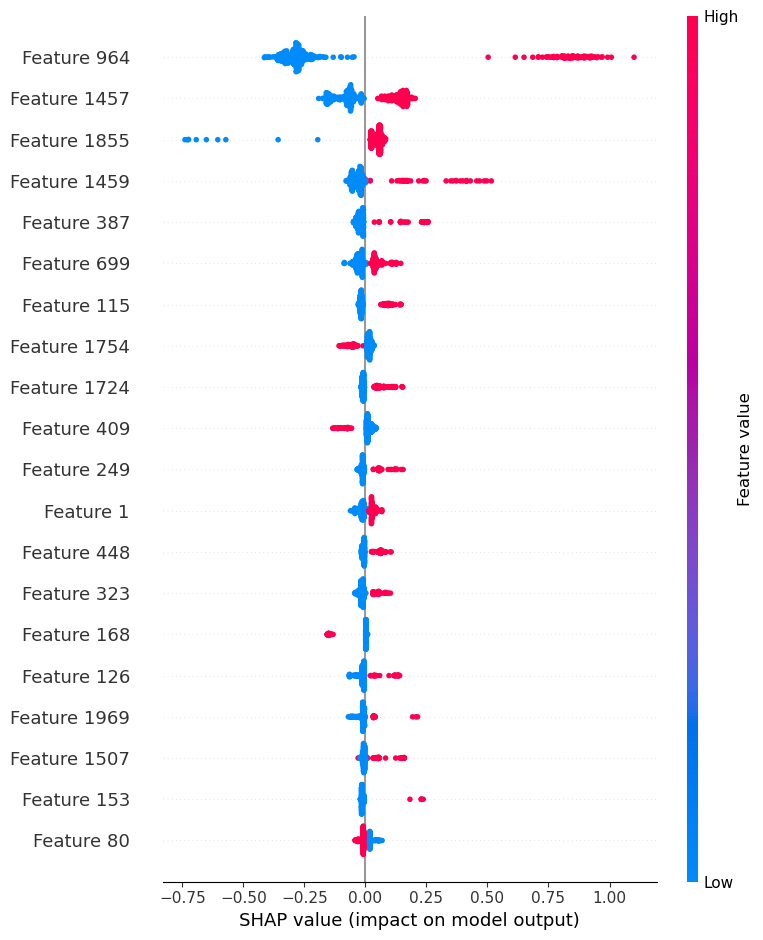

In [30]:
import shap

explainer = shap.Explainer(model)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

In [31]:
import numpy as np
shap_values_array = shap_values.values 
feature_importance = np.abs(shap_values_array).mean(axis=0)
top_bits = np.argsort(feature_importance)[-20:]

print("Top fingerprint bits driving activity:",top_bits)

Top fingerprint bits driving activity: [  80  153 1507 1969  126  168  323  448    1  249  409 1724 1754  115
  699  387 1459 1855 1457  964]


In [49]:
from rdkit import Chem
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from rdkit.Chem import Draw, rdMolDescriptors

def visualize_morgan_bit(mol, bit_id, radius=2, nBits=2048, img_size=(300, 300)):
    """
    Visualize the substructure corresponding to a Morgan fingerprint bit.
    Returns a PIL image with highlighted atoms.
    """

    bitInfo = {}
    gen = GetMorganGenerator(radius=2, fpSize=2048)
    fp = gen.GetFingerprint(mol)

    # If the molecule does not contain this bit
    if bit_id not in bitInfo:
        return Draw.MolToImage(mol, size=img_size)

    # Extract the first environment that triggered this bit
    atom_idx, rad = bitInfo[bit_id][0]

    # Find bonds in the atom environment
    env_bonds = Chem.FindAtomEnvironmentOfRadiusN(mol, rad, atom_idx)

    # Collect atoms in the environment
    env_atoms = set()
    for b in env_bonds:
        bond = mol.GetBondWithIdx(b)
        env_atoms.add(bond.GetBeginAtomIdx())
        env_atoms.add(bond.GetEndAtomIdx())

    # Draw highlighted substructure
    return Draw.MolToImage(
        mol,
        highlightAtoms=list(env_atoms),
        highlightColor=(0.9, 0.2, 0.2),
        size=img_size
    )


In [53]:
def mol_has_bit(mol, bit_id, radius=2, nBits=2048):
    bit_id = int(bit_id)
    gen = GetMorganGenerator(radius=2, fpSize=2048)
    fp = gen.GetFingerprint(mol)
    return fp[bit_id] == 1


In [54]:
smiles_list = df["canonical_smiles"].tolist()

mols = [Chem.MolFromSmiles(s) for s in smiles_list]



=== Bit 80 ===
Appears in 1159 molecules


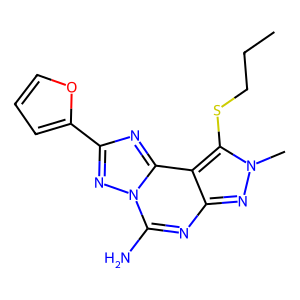

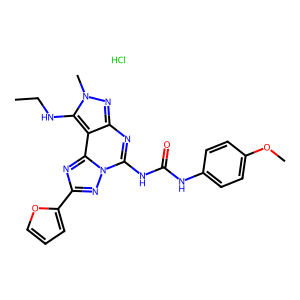

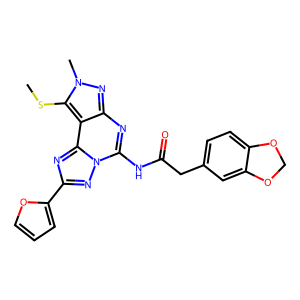


=== Bit 153 ===
Appears in 66 molecules


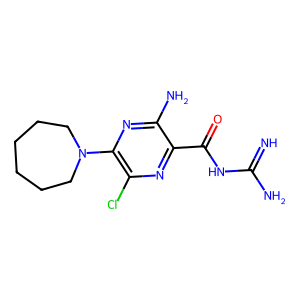

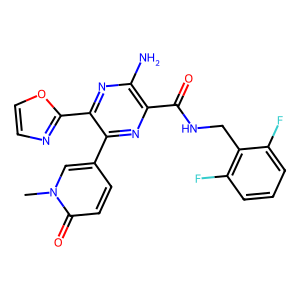

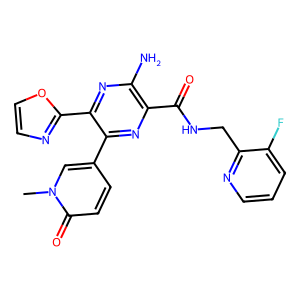


=== Bit 1507 ===
Appears in 143 molecules


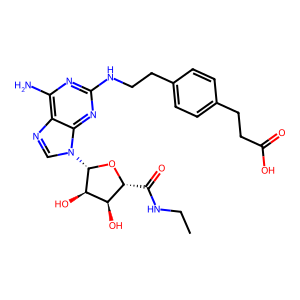

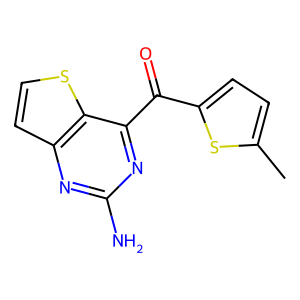

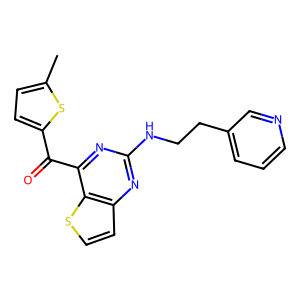


=== Bit 1969 ===
Appears in 129 molecules


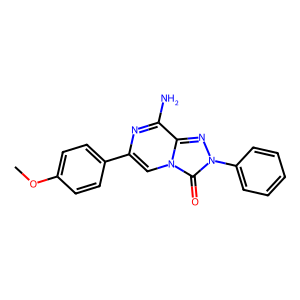

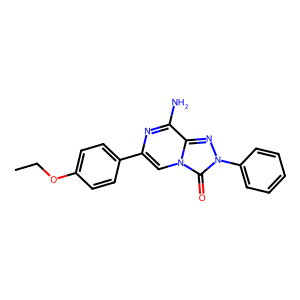

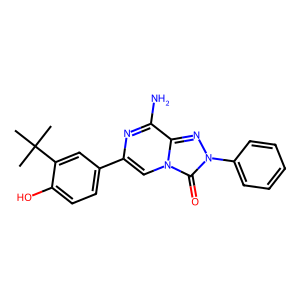


=== Bit 126 ===
Appears in 147 molecules


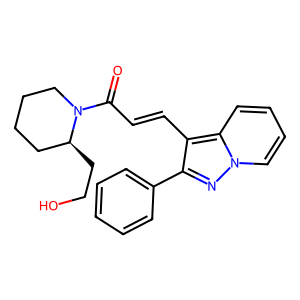

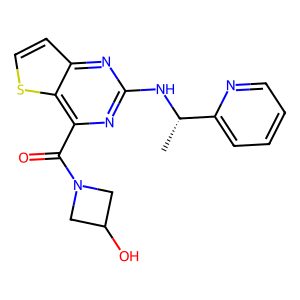

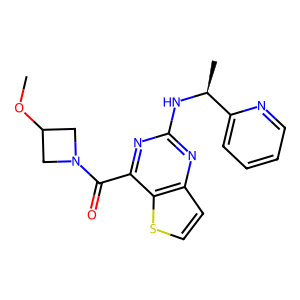


=== Bit 168 ===
Appears in 60 molecules


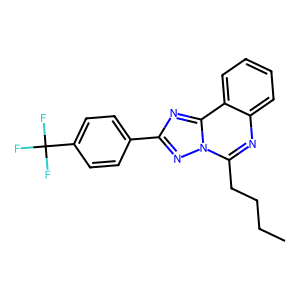

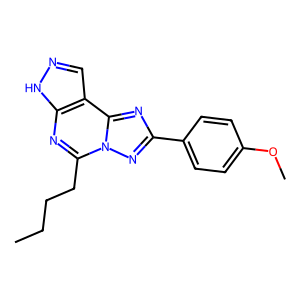

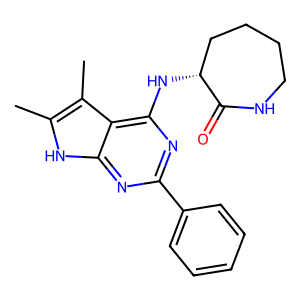


=== Bit 323 ===
Appears in 367 molecules


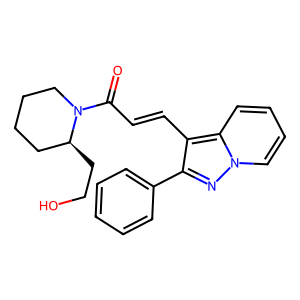

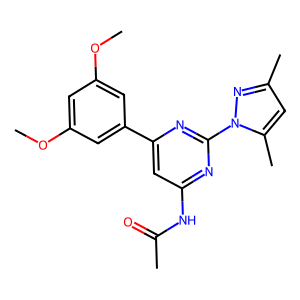

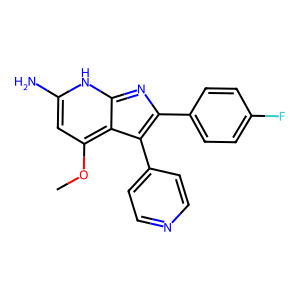


=== Bit 448 ===
Appears in 286 molecules


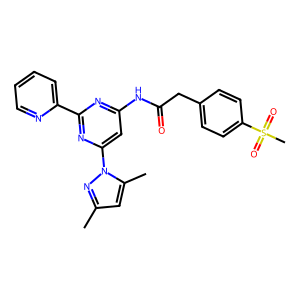

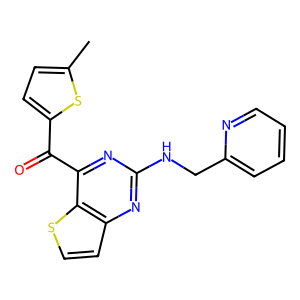

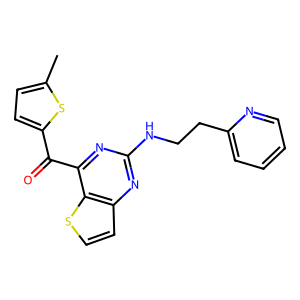


=== Bit 1 ===
Appears in 708 molecules


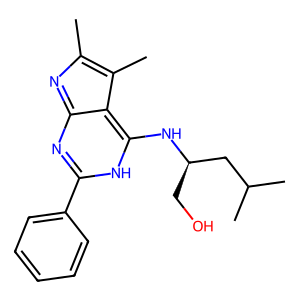

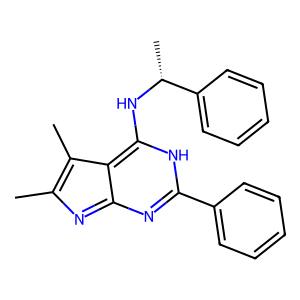

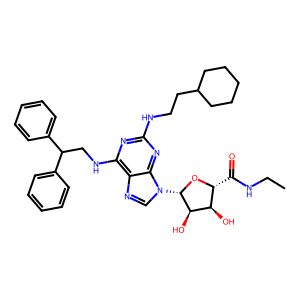


=== Bit 249 ===
Appears in 239 molecules


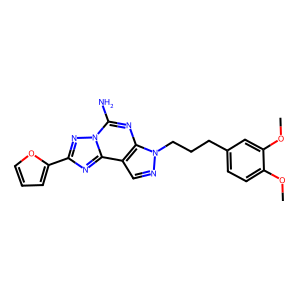

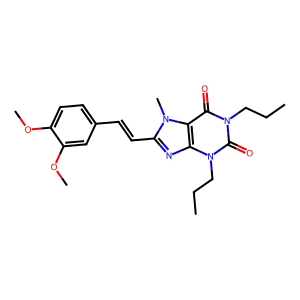

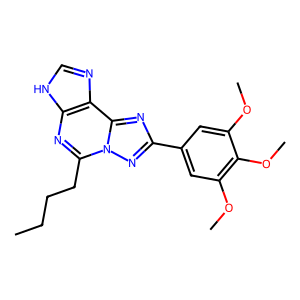


=== Bit 409 ===
Appears in 187 molecules


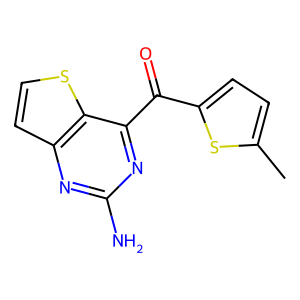

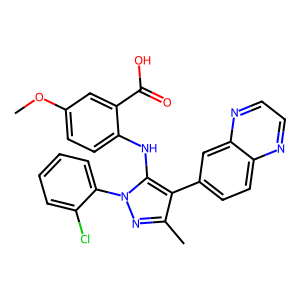

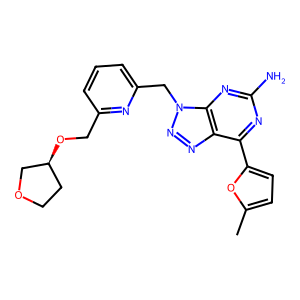


=== Bit 1724 ===
Appears in 311 molecules


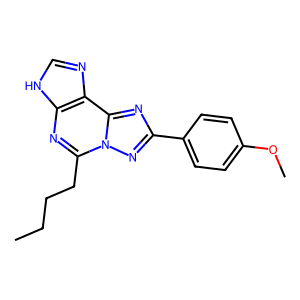

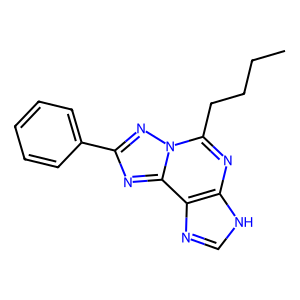

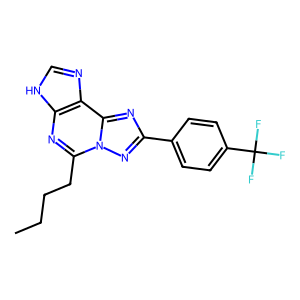


=== Bit 1754 ===
Appears in 352 molecules


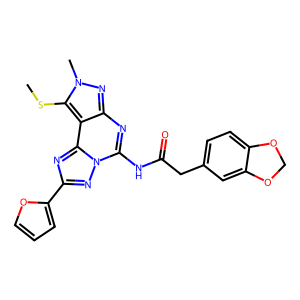

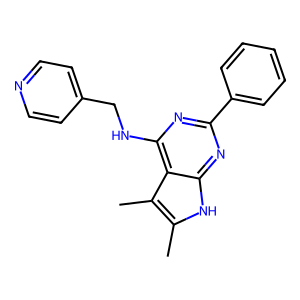

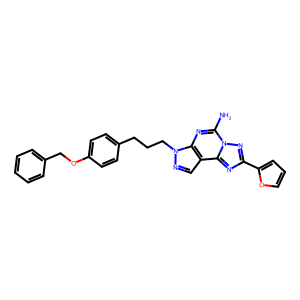


=== Bit 115 ===
Appears in 313 molecules


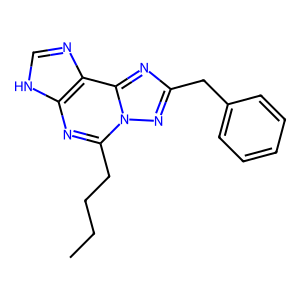

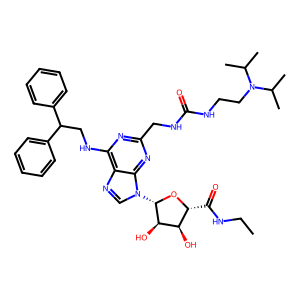

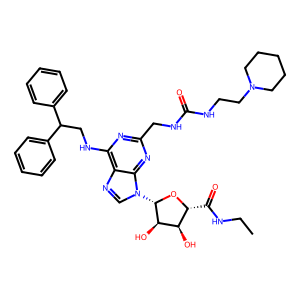


=== Bit 699 ===
Appears in 694 molecules


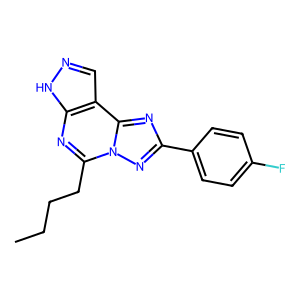

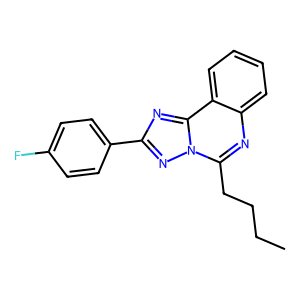

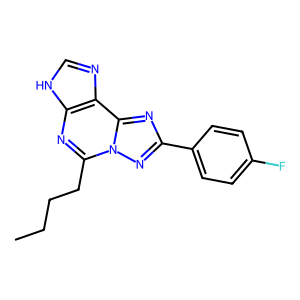


=== Bit 387 ===
Appears in 160 molecules


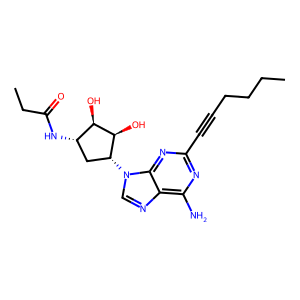

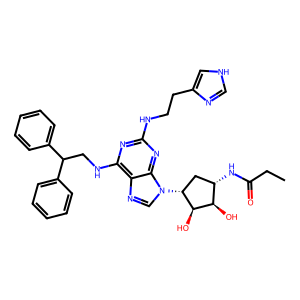

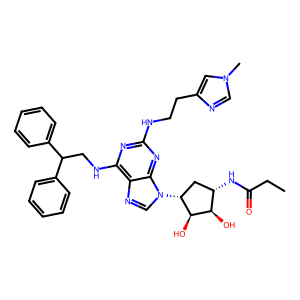


=== Bit 1459 ===
Appears in 184 molecules


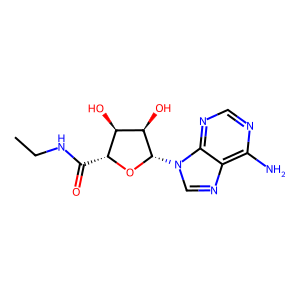

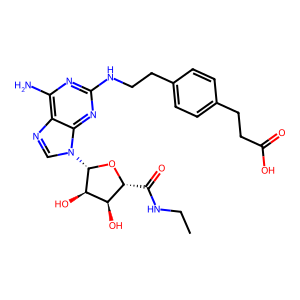

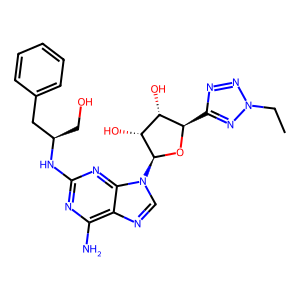


=== Bit 1855 ===
Appears in 1657 molecules


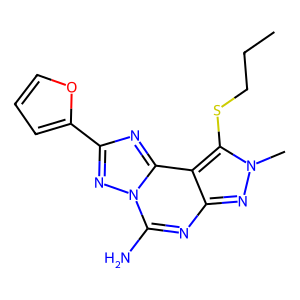

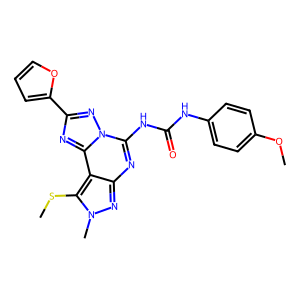

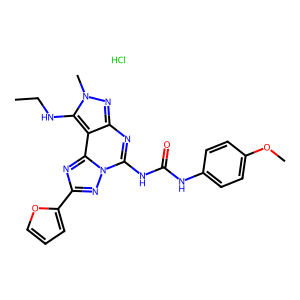


=== Bit 1457 ===
Appears in 790 molecules


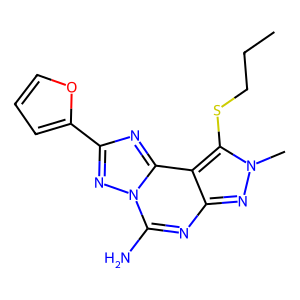

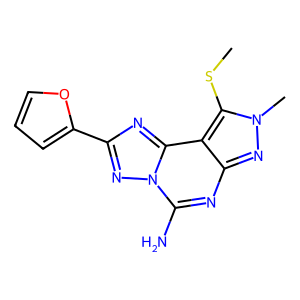

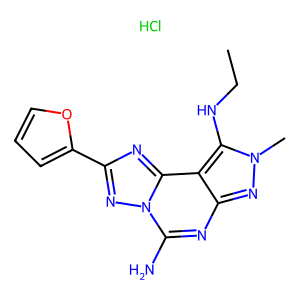


=== Bit 964 ===
Appears in 387 molecules


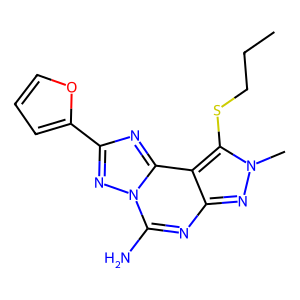

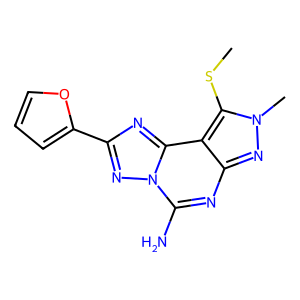

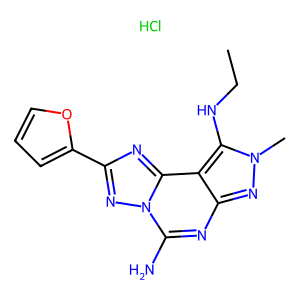

In [55]:
for bit in top_bits:
    print(f"\n=== Bit {bit} ===")
    
    carriers = [m for m in mols if mol_has_bit(m, bit)]
    print(f"Appears in {len(carriers)} molecules")

    # visualize first few molecules that contain this bit
    for m in carriers[:3]:
        display(visualize_morgan_bit(m, bit))
